# Lab 11 (Week 3 — Lab 1): Neural Network Fundamentals

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad

Welcome to Week 3 and Deep Learning! Before using any deep learning framework, this lab focuses on understanding exactly what a neural network computes — by implementing a neuron, a small forward pass, a loss calculation, and a gradient descent step yourself, using plain NumPy.

**For detailed theory — layers, activation functions, backpropagation — see the Lab 11 PDF and Learning Resources.**

**Note:** We are not training a real model with Keras in this lab — that starts in Lab 12 (Building Models with TensorFlow/Keras). Here, the goal is to understand the mechanics first.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## A Real Feature Vector to Work With

We'll use one real sample from the Wine dataset (built into scikit-learn, no download needed) so the numbers in this lab mean something real, even though we aren't training a model yet.

In [71]:
from sklearn.datasets import load_wine
import numpy as np

wine = load_wine()
X = wine.data
y = wine.target

print("Dataset shape:", X.shape)
first_sample = X[0]
print("First sample (13 features):", first_sample)
print("First sample's true class:", y[0])

Dataset shape: (178, 13)
First sample (13 features): [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
First sample's true class: 0


## Example 1: A Single Neuron, Computed by Hand

In [72]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# A single neuron with 3 made-up inputs (for simplicity, not the full 13-feature sample yet)
x = np.array([1.5, 2.0, 0.5])
w = np.array([0.4, -0.2, 0.9])
b = 0.1

z = np.dot(x, w) + b
output = relu(z)

print("Weighted sum (z):", z)
print("Neuron output (after ReLU):", output)

Weighted sum (z): 0.7500000000000001
Neuron output (after ReLU): 0.7500000000000001


## Example 2: Manual Forward Propagation (Two Layers)

In [73]:
X_toy = np.array([1.5, 2.0, 0.5])

W1 = np.array([[0.2, -0.5],
               [0.4,  0.1],
               [-0.3, 0.8]])
b1 = np.array([0.1, -0.2])

W2 = np.array([0.6, -0.9])
b2 = 0.05

hidden_z = np.dot(X_toy, W1) + b1
hidden_a = relu(hidden_z)

output_z = np.dot(hidden_a, W2) + b2
output = sigmoid(output_z)

print("Hidden layer activations:", hidden_a)
print("Final output (probability):", output)

Hidden layer activations: [1.05 0.  ]
Final output (probability): 0.6637386974043528


## Example 3: Calculating Loss

In [74]:
y_true = 1

mse = (y_true - output) ** 2
bce = -(y_true * np.log(output) + (1 - y_true) * np.log(1 - output))

print("Mean Squared Error:", mse)
print("Binary Cross-Entropy:", bce)

Mean Squared Error: 0.11307166362332144
Binary Cross-Entropy: 0.40986673496366205


## Example 4: One Gradient Descent Step, by Hand

In [75]:
w = 0.5
x_val, y_true_val = 2.0, 3.0
learning_rate = 0.1

prediction = w * x_val
loss = (prediction - y_true_val) ** 2

gradient = 2 * (prediction - y_true_val) * x_val
w_new = w - learning_rate * gradient

print("Prediction before update:", prediction)
print("Loss before update:", loss)
print("Gradient:", gradient)
print("Updated weight:", w_new)

Prediction before update: 1.0
Loss before update: 4.0
Gradient: -8.0
Updated weight: 1.3


## Practice Exercise 1: Try a Different Activation

**Exercise:** Repeat Example 1 (the single neuron), but use `sigmoid` instead of `relu` as the activation function. Print the new output.

In [76]:
### YOUR CODE HERE ###
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

x = np.array([1.5, 2.0, 0.5])
w = np.array([0.4, -0.2, 0.9])
b = 0.1

z = np.dot(x, w) + b
output_sigmoid = sigmoid(z)
### END ###

print("Neuron output (sigmoid):", output_sigmoid)

Neuron output (sigmoid): 0.6791786991753931


## Practice Exercise 2: Forward Pass with a Real Wine Sample

**Exercise:** Using the `first_sample` from the Wine dataset (13 features), create a random weight vector `w_wine` of 13 values (use `np.random.randn(13)`) and a bias `b_wine = 0.1`. Compute the weighted sum and apply ReLU, just like Example 1.

In [77]:
np.random.seed(42)
b_wine = 0.1

### YOUR CODE HERE ###
def relu(z):
  return np.maximum(0, z)

w_wine = np.random.randn(13)
z_wine = np.dot(first_sample, w_wine) + b_wine
output_wine = relu(z_wine)
### END ###

print("Output for first wine sample:", output_wine)

Output for first wine sample: 264.2863167055308


## Practice Exercise 3: Multiple Gradient Descent Steps

**Exercise:** Repeat Example 4's gradient descent step 5 times in a row (using a loop), updating `w` each time. Print the weight and loss after each step. Does the loss get smaller each time?

In [78]:
w = 0.5
x_val, y_true_val = 2.0, 3.0
learning_rate = 0.1

### YOUR CODE HERE ###
for step in range(5):
  prediction = w * x_val
  loss = (prediction - y_true_val) ** 2

  gradient = 2 * (prediction - y_true_val) * x_val
  w = w - learning_rate * gradient
  print(f"After {step}: Weight updated = {w:.4f},  Loss = {loss:.4f}")
### END ###

After 0: Weight updated = 1.3000,  Loss = 4.0000
After 1: Weight updated = 1.4600,  Loss = 0.1600
After 2: Weight updated = 1.4920,  Loss = 0.0064
After 3: Weight updated = 1.4984,  Loss = 0.0003
After 4: Weight updated = 1.4997,  Loss = 0.0000


### **Observation**

At every step, the **loss decreases**. As the **weight** moves **closer to the ideal value** (**1.5**), the **prediction** gets **closer to the true target value** (**3.0**), due to which the error/loss continues to reduce. This shows that **gradient descent** is successfully **minimizing the loss**.

## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build a 3-Layer Forward Pass by Hand**: Using NumPy, manually compute a forward pass through a network with 2 hidden layers (your choice of size, e.g. 4 neurons then 3 neurons) and 1 output neuron, using any real wine sample as input. Use ReLU for hidden layers and sigmoid for the output.
2. **Try All Activation Functions**: For the same weighted sum `z`, compute and print the output using ReLU, Sigmoid, and Tanh (`np.tanh()`). Compare the three outputs in a markdown cell.
3. **Loss Comparison**: For 3 different made-up predictions (e.g., 0.9, 0.5, 0.1) against a true label of 1, compute both MSE and Binary Cross-Entropy for each. In a markdown cell, describe how the two loss functions behave differently as the prediction gets further from the true label.
4. **Gradient Descent Over Many Steps**: Extend Practice Exercise 3 to run 20 steps instead of 5. Plot the loss at each step using Matplotlib. Does it flatten out, and if so, around which step?
5. **Reflection**: In a markdown cell, write 3-4 sentences on how implementing these steps manually changed (or didn't change) your understanding of what a neural network actually does internally.

In [79]:
# Task 1
import numpy as np

def relu(z):
  return np.maximum(0, z)

np.random.seed(42)

third_sample = X[2]
x = third_sample

W_1 = np.random.randn(13, 4) * 0.1
b_1 = np.zeros(4)

W_2 = np.random.randn(4, 3) * 0.1
b_2 = np.zeros(3)

W_3 = np.random.randn(3) * 0.1
b_3 = 0.0

z_1 = np.dot(x, W_1) + b_1
output_1 = relu(z_1)

z_2 = np.dot(output_1, W_2) + b_2
output_2 = relu(z_2)

z_3 = np.dot(output_2, W_3) + b_3
final_output = sigmoid(z_3)

print("Hidden layer 1 activations: ", output_1)
print("Hidden layer 2 activations: ", output_2)
print("Final output (probability): ", final_output)

Hidden layer 1 activations:  [31.35048367  0.         26.07260582  0.        ]
Hidden layer 2 activations:  [0.         4.46113511 1.98290127]
Final output (probability):  0.6435390711091867


In [80]:
# Task 2
z = 1.2

output_relu = relu(z)
out_sigmoid = sigmoid(z)
output_tanh = np.tanh(z)

print("ReLU output: ", output_relu)
print("Sigmoid output: ", out_sigmoid)
print("Tanh output: ", output_tanh)


ReLU output:  1.2
Sigmoid output:  0.7685247834990175
Tanh output:  0.8336546070121552


### **ReLU vs Sigmoid vs Tanh Outputs (for z = 1.2)**

- **ReLU (Rectified Linear Unit)** outputs the input value directly (**z = 1.2**) if it is positive. It is simple and prevents the losing gradient problem for positive inputs.

- **Sigmoid** outputs a particular value between 0 and 1 (**~0.77**). Although it is useful for displaying probabilities as output values, it can saturate.

- **Tanh** outputs a value between -1 and 1 (**~0.83**). Since it is zero-centered, it can help in training a neural network unlike sigmoid.

Hence, **ReLU** is considered the **most common and ideal choice** for **hidden layers** of the network, whereas **Sigmoid** is generally used in the **output layer** of the network for **binary classification**.



In [81]:
# Task 3
y_true_label = 1
predictions = [0.9, 0.5, 0.1]

print("Predictions    |    Mean Squared Error (MSE)    |      Binary Cross-Entropy (BCE)")

for p in predictions:
  mse = (y_true_label - p) ** 2
  bce = -(y_true_label * np.log(p) + (1 - y_true_label) * np.log(1 - p))

  print(f"    {p}        |        {mse:.4f}                  |                {bce:.4f}    ")

Predictions    |    Mean Squared Error (MSE)    |      Binary Cross-Entropy (BCE)
    0.9        |        0.0100                  |                0.1054    
    0.5        |        0.2500                  |                0.6931    
    0.1        |        0.8100                  |                2.3026    


### **How MSE and BCE behave as the prediction(s) moves further from the true label value?**

- When the prediction(s) is **close to the true label** (**0.9**), **both Mean Squared Error and Binary Cross-Entropy** output **small values**.

- As the prediction **moves further away from the true label** (i.e. **from 0.5 to 0.1**), **BCE increases much more sharply** than MSE.  

This shows that **BCE avoids wrong predictions more heavily**, which is why it is preferred for many **classification tasks**. Since **MSE grows more gradually**, it is mainly used for **regression problems**.

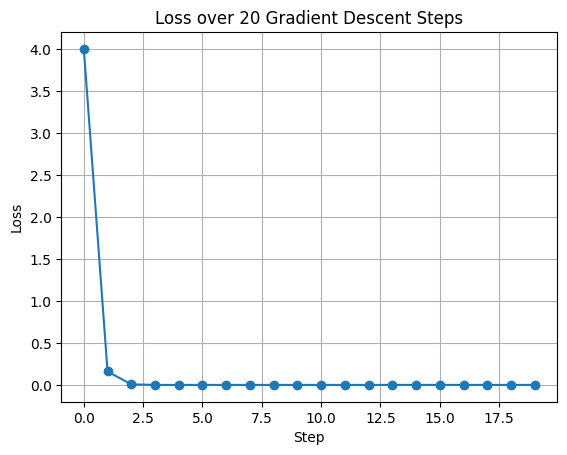

Final adjusted weight:  1.4999999999999896
Final loss:  1.0984099244297368e-26


In [87]:
# Task 4
import matplotlib.pyplot as plt

w = 0.5
x_val, y_true_val = 2.0, 3.0
learning_rate = 0.1

losses = []

for step in range(20):
    prediction = w * x_val
    loss = (prediction - y_true_val) ** 2

    gradient = 2 * (prediction - y_true_val) * x_val
    w = w - learning_rate * gradient
    losses.append(loss)

plt.plot(range(20), losses, marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss over 20 Gradient Descent Steps")
plt.grid(True)
plt.show()

print("Final adjusted weight: ", w)
print("Final loss: ", losses[-1])

### **Around what step does the loss flatten out?**

Observing the above plot:

- The **loss drops very sharply** in the **first 2–3 steps**.

- **After around step 3-4**, the **loss becomes almost zero** and **stays flat for the remaining steps**.

Therefore, the **curve flattens out around step 3–4**.

## **Task 5**

Implementing a neuron, forward propagation, loss, and gradient descent manually made the internal workings of a neural network much clearer. Initially, training a model felt like a black box, but now it is obvious that the network is simply adjusting weights to minimize error/loss via repeated minor updates. Observing the loss decrease with each step also helped build intuition for why both learning rate and the number of iterations matter. Overall, this hands-on practical approach strengthened the understanding of what deep-learning frameworks like Keras are actually doing behind the scenes.

In [88]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 108 (delta 51), reused 53 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 1.48 MiB | 23.24 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/YourNotebook.ipynb" "/content/your-repo/"